# Experiment B: Do Rhetorical Figures Correspond to Separable Internal Representations?

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

main_dir = "/content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes"

Mounted at /content/drive


## Setup

In [ ]:
!git clone https://github.com/yc015/TalkTuner-chatbot-llm-dashboard.git
!pip install -q scikit-learn

Cloning into 'TalkTuner-chatbot-llm-dashboard'...
remote: Enumerating objects: 472, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 472 (delta 30), reused 24 (delta 24), pack-reused 431 (from 1)
Receiving objects: 100% (472/472), 48.61 MiB | 22.49 MiB/s, done.
Resolving deltas: 100% (112/112), done.


In [ ]:
%cd /content/TalkTuner-chatbot-llm-dashboard/src

/content/TalkTuner-chatbot-llm-dashboard/src


In [ ]:
import os
import json
import time
from pathlib import Path
from tqdm.auto import tqdm

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

import torch
from torch import nn
from torch.utils.data import Subset, Dataset
from torch.utils.data.dataloader import DataLoader

from probes import LinearProbeClassification

## Load Part A Activations

Each file is a tensor `[200, 32, 4096]` — 200 questions × 32 layers × 4096 dims.
No model needed — probe training and PCA run entirely on these saved tensors.

In [ ]:
CONDITIONS = ["baseline_cot", "enumeratio", "parallelism", "chiasmus"]
condition_to_id = {c: i for i, c in enumerate(CONDITIONS)}
id_to_condition = {i: c for i, c in enumerate(CONDITIONS)}
NUM_CONDITIONS = len(CONDITIONS)
NUM_LAYERS = 32
D_MODEL = 4096

ACTIVATIONS_DIR = os.path.join(main_dir, "partA_activations")

activations = {}
for condition in CONDITIONS:
    path = os.path.join(ACTIVATIONS_DIR, f"{condition}_activations.pt")
    activations[condition] = torch.load(path, map_location="cpu")
    print(f"{condition}: {list(activations[condition].shape)}")

N_PER_CLASS = activations[CONDITIONS[0]].shape[0]  # 200
N_TOTAL = N_PER_CLASS * NUM_CONDITIONS              # 800
print(f"\n{N_PER_CLASS} questions per condition × {NUM_CONDITIONS} conditions = {N_TOTAL} total samples")

baseline_cot: [200, 32, 4096]
enumeratio: [200, 32, 4096]
parallelism: [200, 32, 4096]
chiasmus: [200, 32, 4096]

200 questions per condition × 4 conditions = 800 total samples


## PCA Visualisation

Project the 4096-dim last-token activations to 2D using PCA at **layer 31** (the most downstream transformer layer — highest-level representations).

If rhetorical conditions are separably encoded in the model's representations, the four condition clusters should be visually distinct. No probes required — this is a direct look at the raw activation geometry.

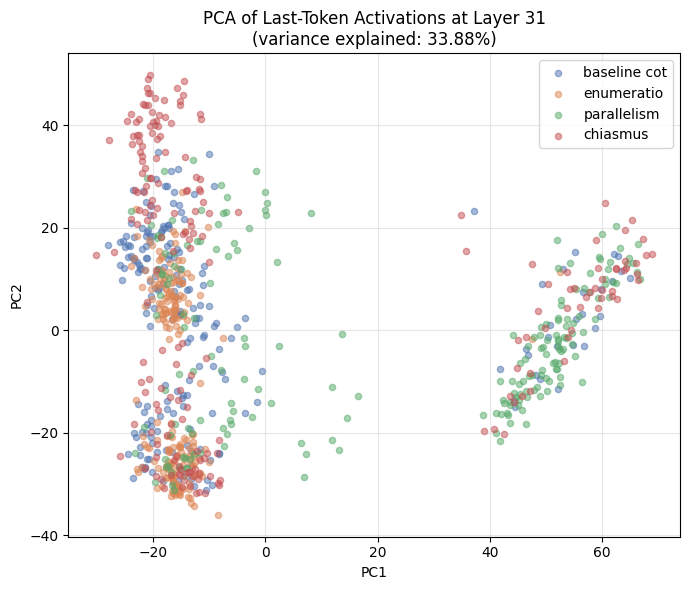

In [ ]:
PCA_LAYER = 31  # most downstream transformer layer
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

X = torch.cat([activations[c][:, PCA_LAYER, :] for c in CONDITIONS], dim=0).numpy()
y = [i for i, c in enumerate(CONDITIONS) for _ in range(N_PER_CLASS)]

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)
var_explained = pca.explained_variance_ratio_.sum()

fig, ax = plt.subplots(figsize=(7, 6))
for i, condition in enumerate(CONDITIONS):
    mask = slice(i * N_PER_CLASS, (i + 1) * N_PER_CLASS)
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        label=condition.replace("_", " "),
        color=colors[i], alpha=0.5, s=20,
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(
    f"PCA of Last-Token Activations at Layer {PCA_LAYER}\n"
    f"(variance explained: {var_explained:.2%})"
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(main_dir, "partB_pca.png"), dpi=150, bbox_inches="tight")
plt.show()

### Representation Input to Probes

Each sample contributes one vector per layer (last-token hidden state), producing a layer-wise representation of the full reasoning trace.

The probe task is 4-class classification over rhetorical condition labels. Running this independently per layer reveals where rhetorical structure becomes linearly decodable.

## Probe Training

Train one `LinearProbeClassification` per layer (32 total). 4-class classification: which rhetorical condition produced this activation?

- **800 samples** total (200 per condition)
- **80/20 stratified split** → 640 train / 160 test (40 per condition in test)
- **Chance level = 0.25** (random baseline for 4 equal classes)
- Adapted from `User_Mental_State_Probing.ipynb`

In [ ]:
class RhetoricalActivationDataset(Dataset):
    """
    Wraps the pre-computed Part A activations.
    Each item: hidden_states [NUM_LAYERS, D_MODEL], label (int 0-3)
    """
    def __init__(self, activations: dict, condition_to_id: dict):
        self.acts = []
        self.labels = []
        for condition, tensor in activations.items():
            for i in range(tensor.shape[0]):
                self.acts.append(tensor[i])           # [NUM_LAYERS, D_MODEL]
                self.labels.append(condition_to_id[condition])

    def __len__(self):
        return len(self.acts)

    def __getitem__(self, idx):
        return {
            "hidden_states": self.acts[idx],
            "label": self.labels[idx],
        }

In [ ]:
def dataset_to_dataloader(dataset: RhetoricalActivationDataset) -> tuple:
    """80/20 stratified train/test split."""
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_idx, val_idx = train_test_split(
        list(range(len(dataset))),
        test_size=test_size,
        train_size=train_size,
        random_state=12345,
        shuffle=True,
        stratify=dataset.labels,
    )
    train_dataset = Subset(dataset, train_idx)
    test_dataset  = Subset(dataset, val_idx)
    train_loader = DataLoader(train_dataset, shuffle=True,  pin_memory=True, batch_size=200, num_workers=0)
    test_loader  = DataLoader(test_dataset,  shuffle=False, pin_memory=True, batch_size=400, num_workers=0)
    print(f"Train: {len(train_dataset)} samples ({len(train_dataset)//NUM_CONDITIONS} per class)")
    print(f"Test:  {len(test_dataset)} samples ({len(test_dataset)//NUM_CONDITIONS} per class)")
    return train_loader, test_loader

In [ ]:
class TrainerConfig:
    learning_rate = 1e-3
    betas = (0.9, 0.95)
    weight_decay = 0.1
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)


class TrainConfig:
    logistic = True
    loss_func = nn.BCELoss()
    num_layers = NUM_LAYERS    # 32
    hidden_size = D_MODEL      # 4096
    checkpoint_dir = "partB_probes"
    device = "cuda"

In [ ]:
def train(probe, train_loader, optimizer, loss_func,
          layer_num=0, device="cuda", return_raw_outputs=False, **kwargs):
    probe.train()
    loss_sum, correct, tot = 0, 0, 0
    preds, truths = [], []
    for _, batch in enumerate(train_loader):
        target = batch["label"].long().to(device)
        target_oh = torch.nn.functional.one_hot(target, **kwargs).float()
        optimizer.zero_grad()
        act = batch["hidden_states"][:, layer_num].to(device)
        output = probe(act)
        loss = loss_func(output[0], target_oh)
        loss.backward()
        optimizer.step()
        loss_sum += loss.sum().item()
        pred = torch.argmax(output[0], dim=1)
        correct += (pred.cpu().numpy() == target.cpu().numpy()).sum()
        tot += pred.shape[0]
        if return_raw_outputs:
            preds.append(pred.cpu().numpy())
            truths.append(target.cpu().numpy())
    if return_raw_outputs:
        return loss_sum / len(train_loader), correct / tot, np.concatenate(preds), np.concatenate(truths)
    return loss_sum / len(train_loader), correct / tot


def test(probe, test_loader, loss_func,
         layer_num=0, device="cuda", return_raw_outputs=False, scheduler=None, **kwargs):
    probe.eval()
    test_loss, correct, tot = 0, 0, 0
    preds, truths = [], []
    with torch.no_grad():
        for _, batch in enumerate(test_loader):
            target = batch["label"].long().to(device)
            target_oh = torch.nn.functional.one_hot(target, **kwargs).float()
            act = batch["hidden_states"][:, layer_num].to(device)
            output = probe(act)
            pred = torch.argmax(output[0], dim=1)
            loss = loss_func(output[0], target_oh)
            test_loss += loss.sum().item()
            correct += (pred.cpu().numpy() == target.cpu().numpy()).sum()
            tot += pred.shape[0]
            if return_raw_outputs:
                preds.append(pred.cpu().numpy())
                truths.append(target.cpu().numpy())
    if scheduler:
        scheduler.step(test_loss / len(test_loader))
    if return_raw_outputs:
        return test_loss / len(test_loader), correct / tot, np.concatenate(preds), np.concatenate(truths)
    return test_loss / len(test_loader), correct / tot

In [ ]:
def fit(config: TrainConfig, train_loader: DataLoader, test_loader: DataLoader) -> tuple:
    """
    Train one LinearProbeClassification per layer (32 total).
    Saves best and final checkpoints per layer.
    Returns (best_accs, train_accs, final_accs).
    """
    Path(os.path.join(main_dir, config.checkpoint_dir)).mkdir(parents=True, exist_ok=True)
    best_accs, train_accs, final_accs = [], [], []

    for layer_num in tqdm(range(config.num_layers), desc="layers"):
        probe = LinearProbeClassification(
            probe_class=NUM_CONDITIONS,
            device=config.device,
            input_dim=config.hidden_size,
            logistic=config.logistic,
        )
        optimizer, scheduler = probe.configure_optimizers(TrainerConfig())
        best_acc = 0

        for epoch in range(1, 51):
            train_results = train(
                probe, train_loader, optimizer, config.loss_func,
                layer_num=layer_num, device=config.device,
                return_raw_outputs=True, num_classes=NUM_CONDITIONS,
            )
            test_results = test(
                probe, test_loader, config.loss_func,
                layer_num=layer_num, device=config.device,
                return_raw_outputs=True, scheduler=scheduler,
                num_classes=NUM_CONDITIONS,
            )
            if test_results[1] > best_acc:
                best_acc = test_results[1]
                torch.save(
                    probe.state_dict(),
                    os.path.join(main_dir, config.checkpoint_dir,
                                 f"rhetorical_probe_at_layer_{layer_num}.pth")
                )

        torch.save(
            probe.state_dict(),
            os.path.join(main_dir, config.checkpoint_dir,
                         f"rhetorical_probe_at_layer_{layer_num}_final.pth")
        )
        best_accs.append(best_acc)
        final_accs.append(test_results[1])
        train_accs.append(train_results[1])

        cm = confusion_matrix(test_results[3], test_results[2])
        ConfusionMatrixDisplay(cm, display_labels=list(condition_to_id.keys())).plot()
        plt.title(f"Layer {layer_num}")
        plt.show()

    return best_accs, train_accs, final_accs

### Interpreting Layer-Wise Probe Curves

Typical interpretation pattern:
- early layers: lexical/surface cues
- middle layers: syntactic organization
- later layers: semantic/abstract structure

A robust rhetorical signal should appear above chance and persist across a contiguous band of layers, not just a single-layer spike.

In [ ]:
def get_probes(checkpoint_dir: str, device: str = "cuda") -> list:
    """Load all saved best probes from checkpoint_dir."""
    probes = []
    for layer_num in range(NUM_LAYERS):
        probe = LinearProbeClassification(
            probe_class=NUM_CONDITIONS,
            device=device,
            input_dim=D_MODEL,
            logistic=True,
        )
        probe.load_state_dict(torch.load(
            os.path.join(main_dir, checkpoint_dir,
                         f"rhetorical_probe_at_layer_{layer_num}_final.pth"),
            weights_only=True,
        ))
        probe.eval()
        probes.append(probe)
    return probes


def plot_accuracy_metrics(best_accs, train_accs, final_accs):
    chance = 1.0 / NUM_CONDITIONS
    plt.figure(figsize=(10, 6))
    plt.axhline(y=chance, color="gray", linestyle="--", label=f"Chance ({chance:.2f})")
    plt.plot(range(len(best_accs)),  best_accs,  label="Best Test Accuracy",  marker="o")
    plt.plot(range(len(train_accs)), train_accs, label="Train Accuracy",       marker="s")
    plt.plot(range(len(final_accs)), final_accs, label="Final Test Accuracy",  marker="^")
    plt.xlabel("Layer Number")
    plt.ylabel("Accuracy")
    plt.title("Rhetorical Condition Probe Accuracy Across Layers")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(main_dir, "partB_probe_accuracy.png"), dpi=150, bbox_inches="tight")
    plt.show()
    best_layer = int(np.argmax(best_accs))
    print(f"Best accuracy: {max(best_accs):.4f} at layer {best_layer}")
    print(f"Chance level:  {chance:.4f}")

## Train Probes

Train: 640 samples (160 per class)
Test:  160 samples (40 per class)


layers:   0%|          | 0/32 [00:00<?, ?it/s]

Decayed: {'proj.0.bias', 'proj.0.weight'}


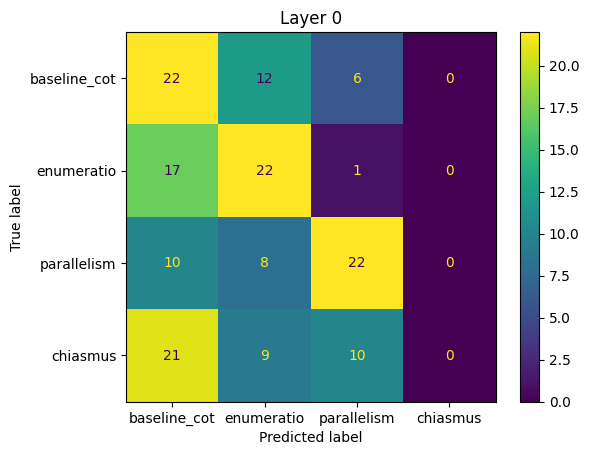

Decayed: {'proj.0.bias', 'proj.0.weight'}


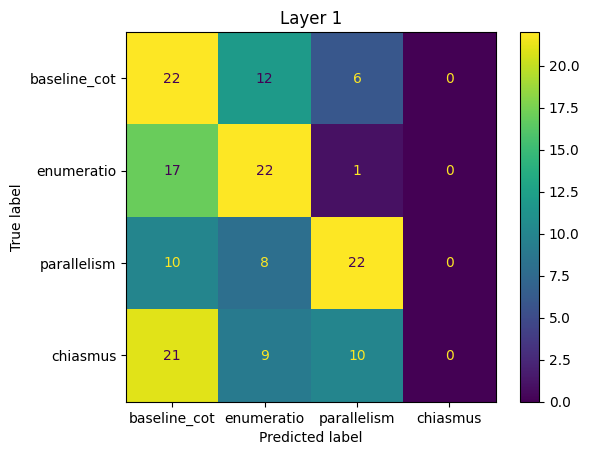

Decayed: {'proj.0.bias', 'proj.0.weight'}


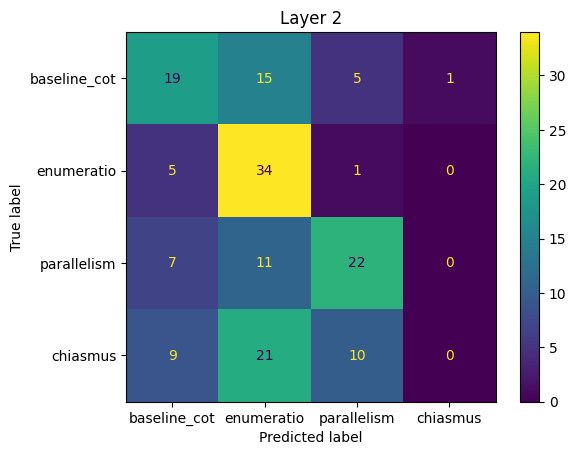

Decayed: {'proj.0.bias', 'proj.0.weight'}


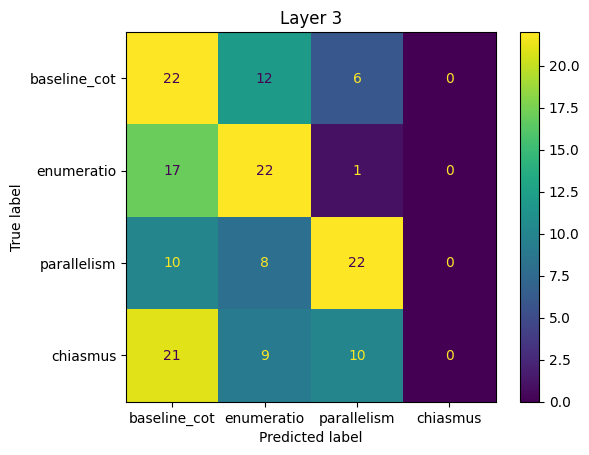

Decayed: {'proj.0.bias', 'proj.0.weight'}


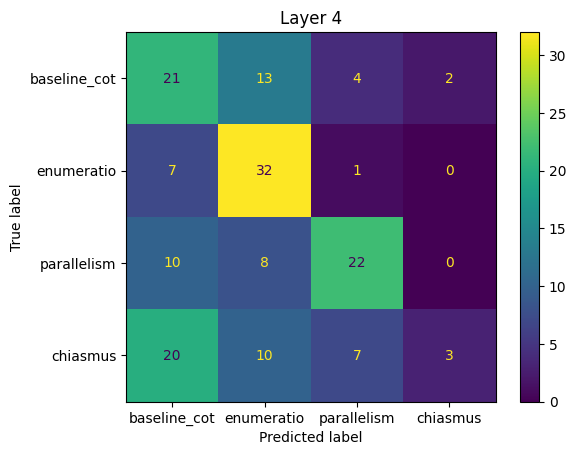

Decayed: {'proj.0.bias', 'proj.0.weight'}


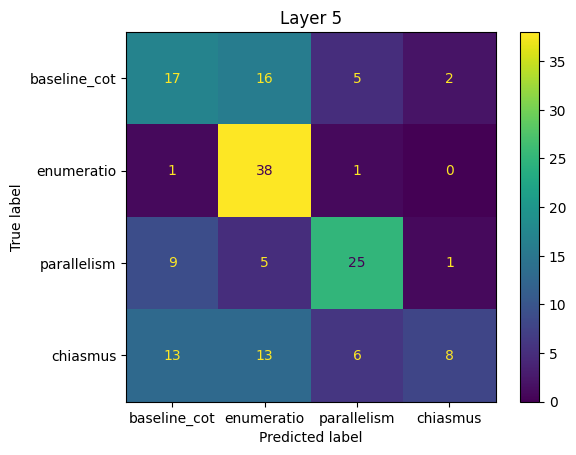

Decayed: {'proj.0.bias', 'proj.0.weight'}


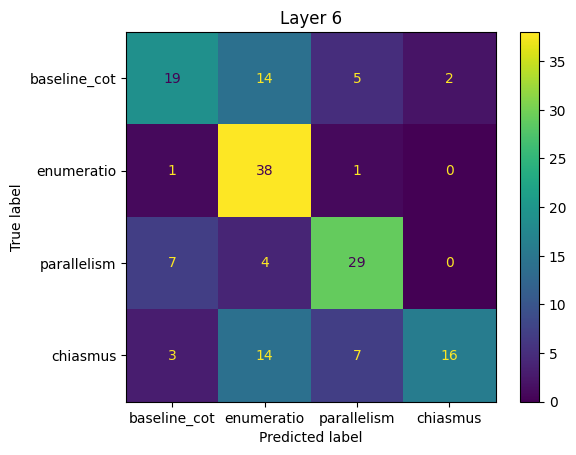

Decayed: {'proj.0.bias', 'proj.0.weight'}


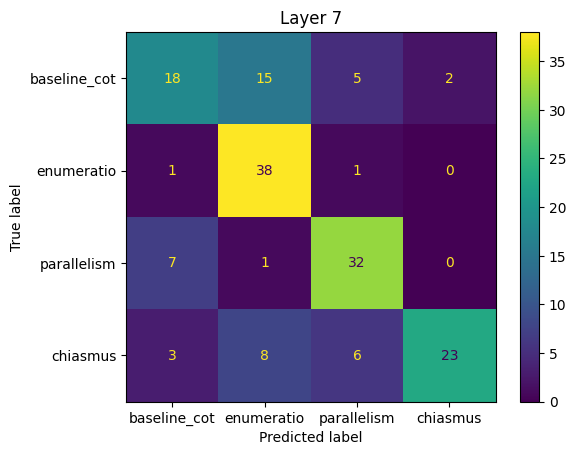

Decayed: {'proj.0.bias', 'proj.0.weight'}


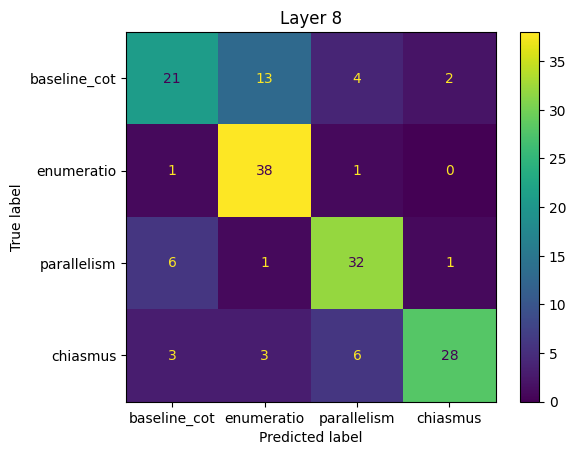

Decayed: {'proj.0.bias', 'proj.0.weight'}


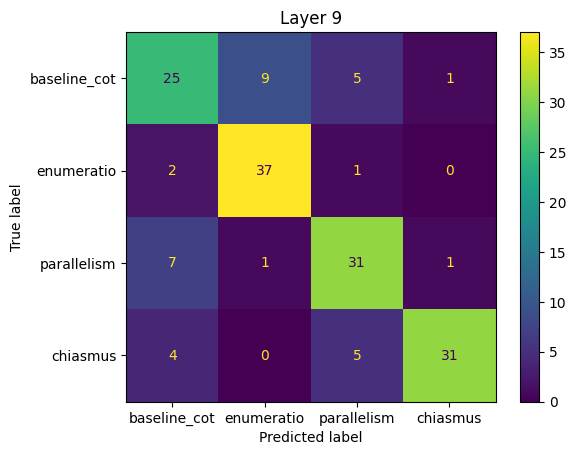

Decayed: {'proj.0.bias', 'proj.0.weight'}


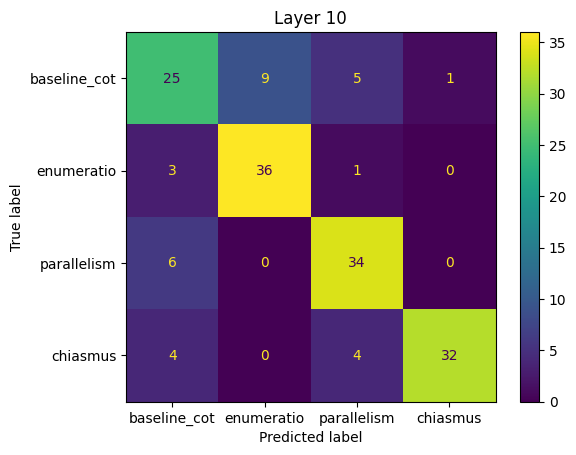

Decayed: {'proj.0.bias', 'proj.0.weight'}


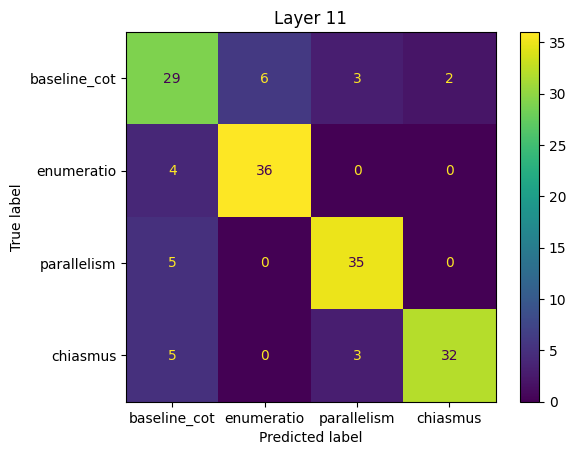

Decayed: {'proj.0.bias', 'proj.0.weight'}


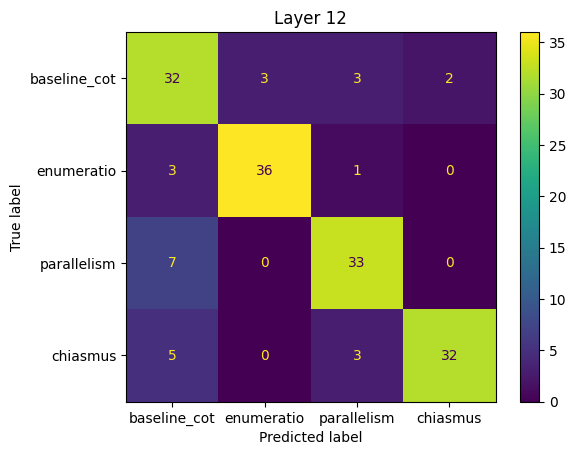

Decayed: {'proj.0.bias', 'proj.0.weight'}


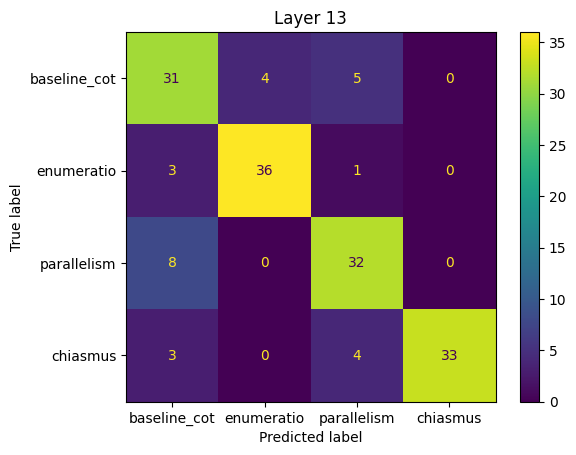

Decayed: {'proj.0.bias', 'proj.0.weight'}


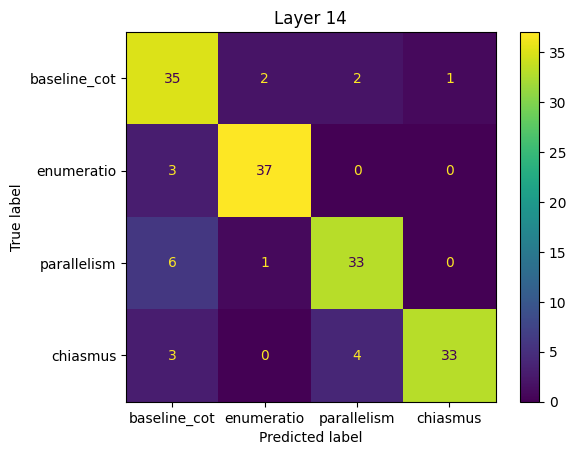

Decayed: {'proj.0.bias', 'proj.0.weight'}


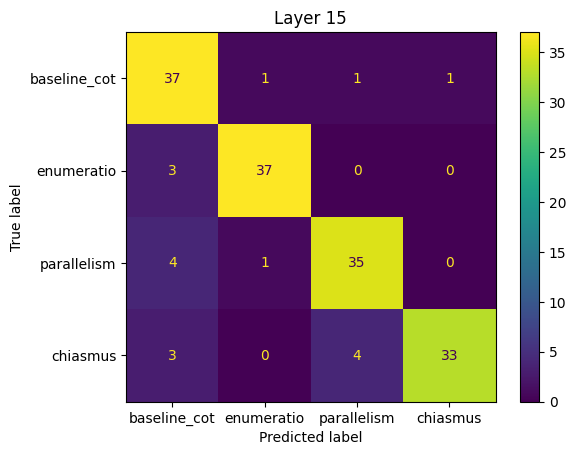

Decayed: {'proj.0.bias', 'proj.0.weight'}


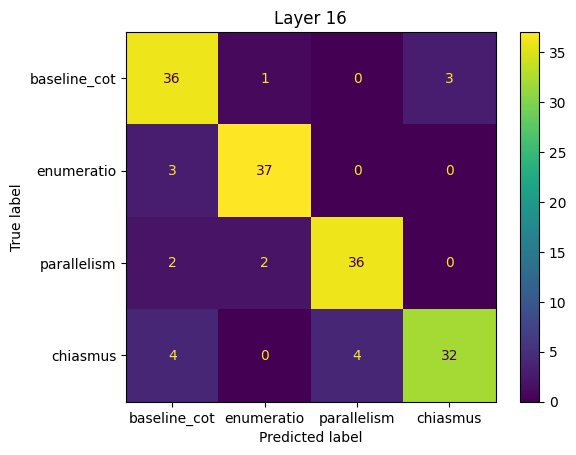

Decayed: {'proj.0.bias', 'proj.0.weight'}


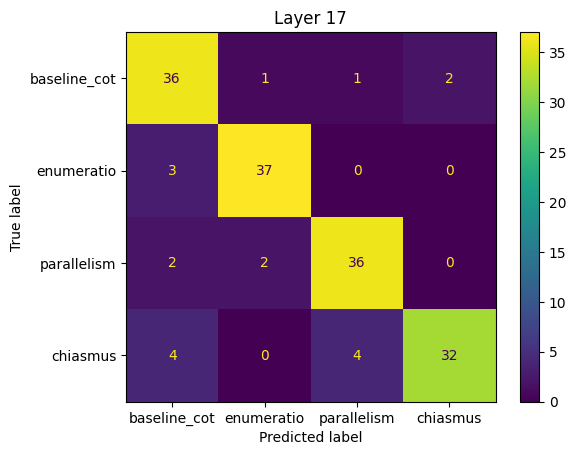

Decayed: {'proj.0.bias', 'proj.0.weight'}


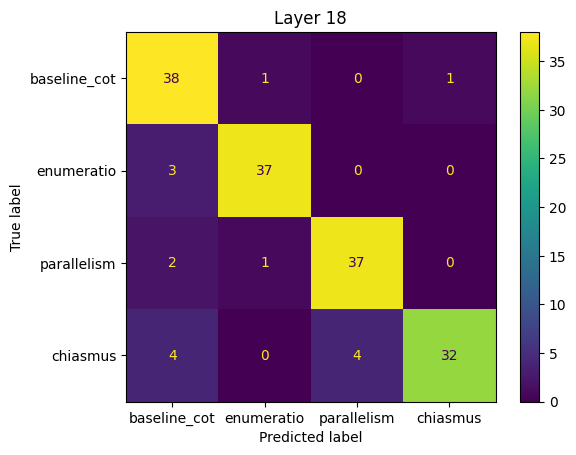

Decayed: {'proj.0.bias', 'proj.0.weight'}


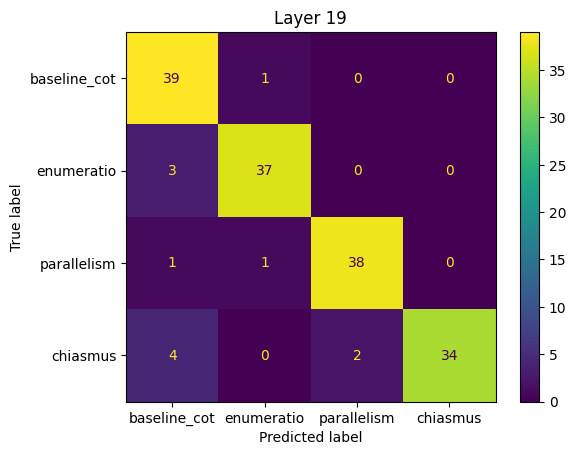

Decayed: {'proj.0.bias', 'proj.0.weight'}


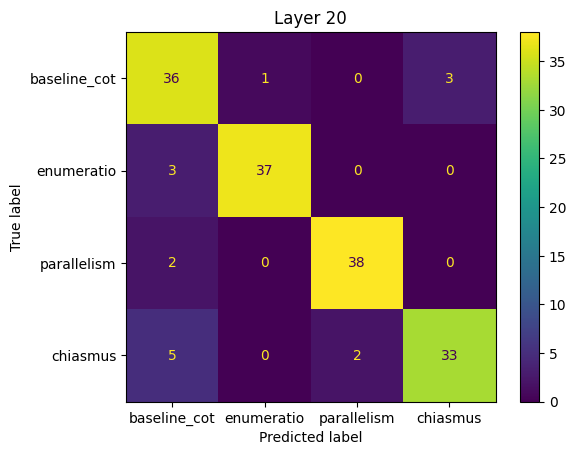

Decayed: {'proj.0.bias', 'proj.0.weight'}


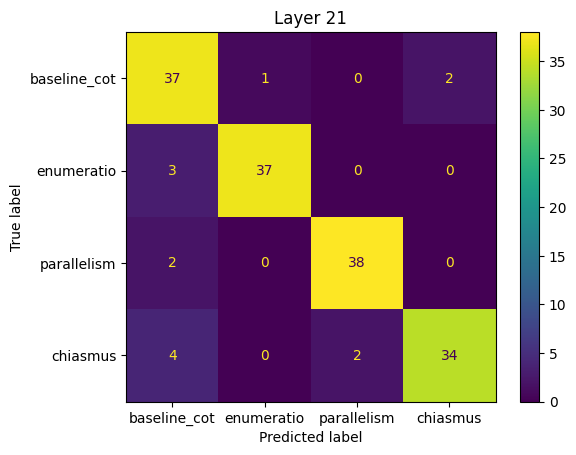

Decayed: {'proj.0.bias', 'proj.0.weight'}


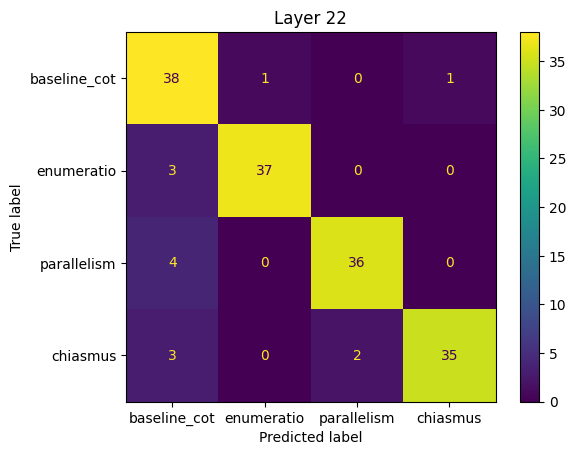

Decayed: {'proj.0.bias', 'proj.0.weight'}


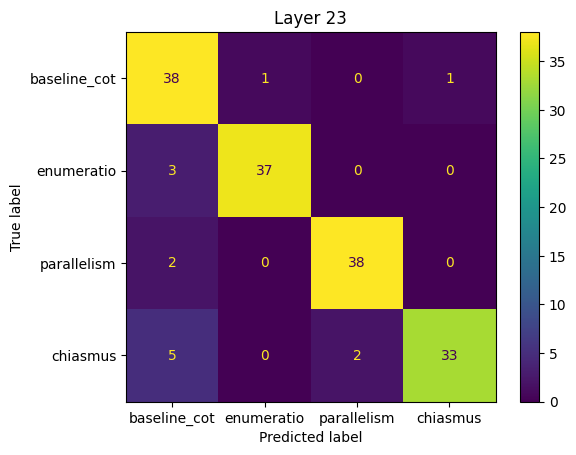

Decayed: {'proj.0.bias', 'proj.0.weight'}


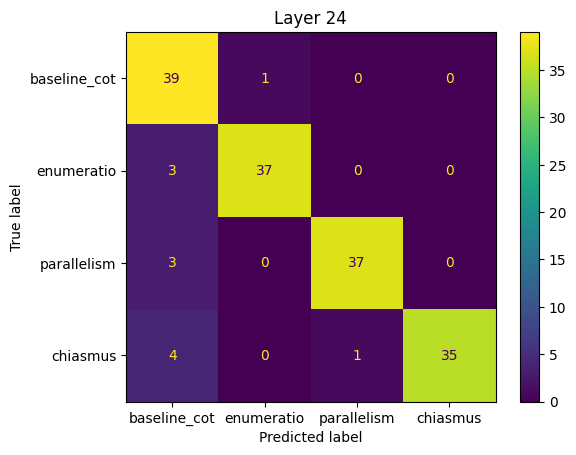

Decayed: {'proj.0.bias', 'proj.0.weight'}


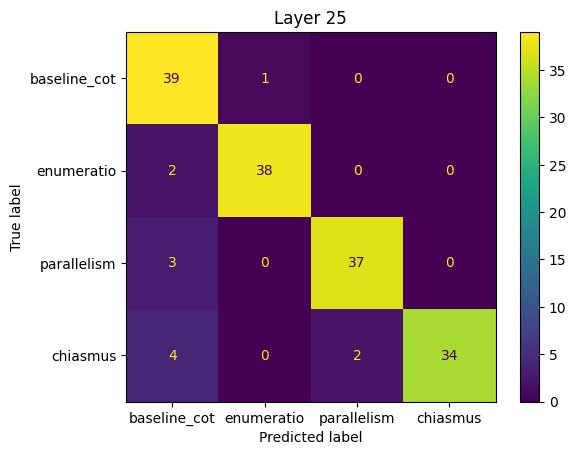

Decayed: {'proj.0.bias', 'proj.0.weight'}


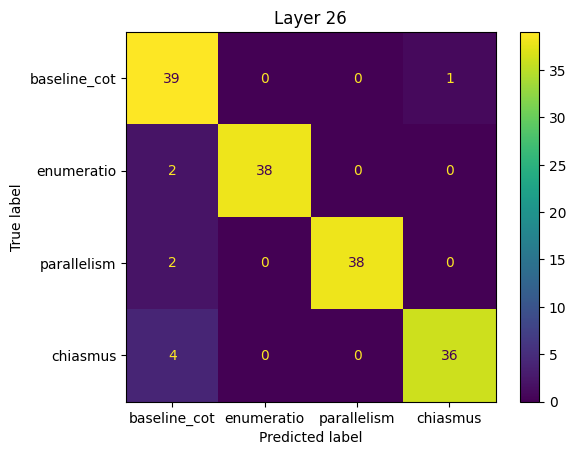

Decayed: {'proj.0.bias', 'proj.0.weight'}


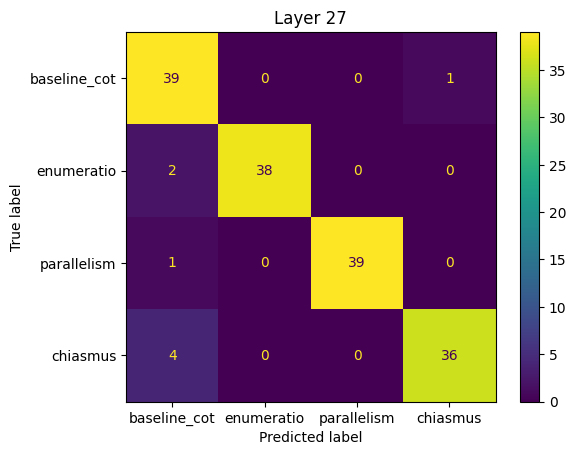

Decayed: {'proj.0.bias', 'proj.0.weight'}


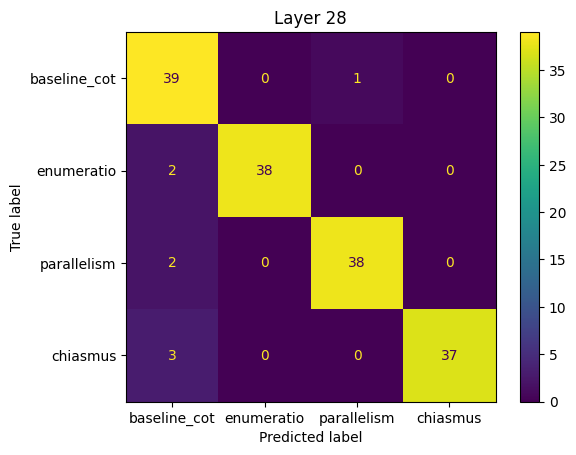

Decayed: {'proj.0.bias', 'proj.0.weight'}


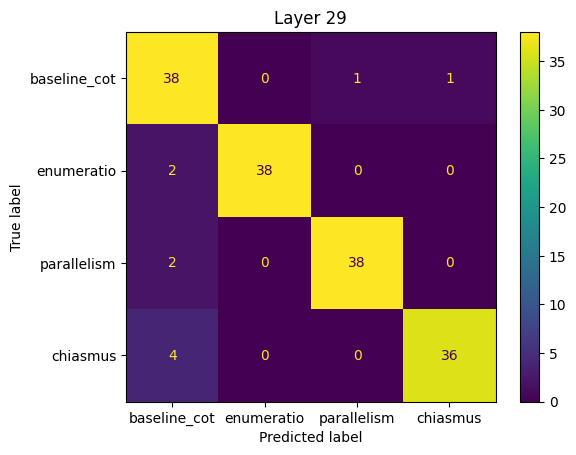

Decayed: {'proj.0.bias', 'proj.0.weight'}


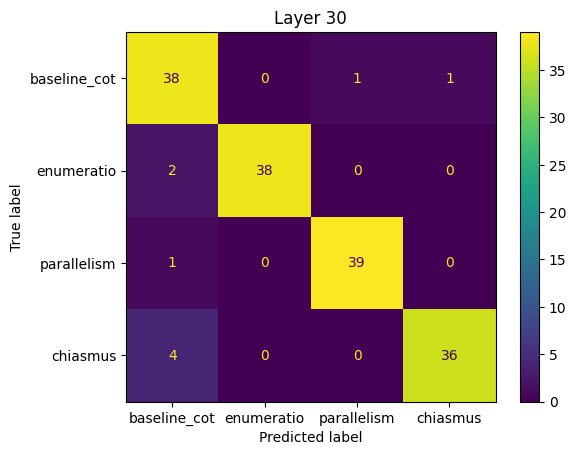

Decayed: {'proj.0.bias', 'proj.0.weight'}


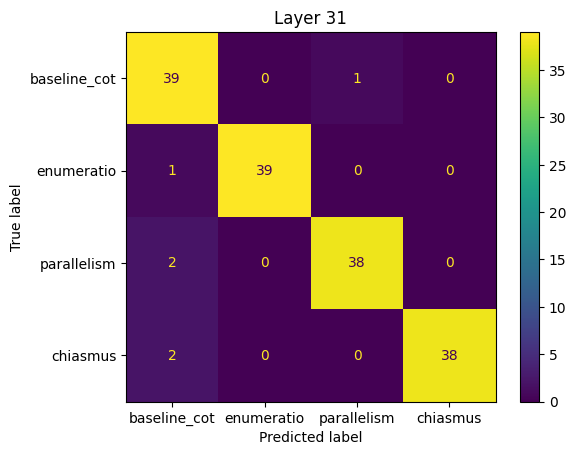

In [ ]:
dataset = RhetoricalActivationDataset(activations, condition_to_id)
train_loader, test_loader = dataset_to_dataloader(dataset)

train_config = TrainConfig()
best_accs, train_accs, final_accs = fit(train_config, train_loader, test_loader)

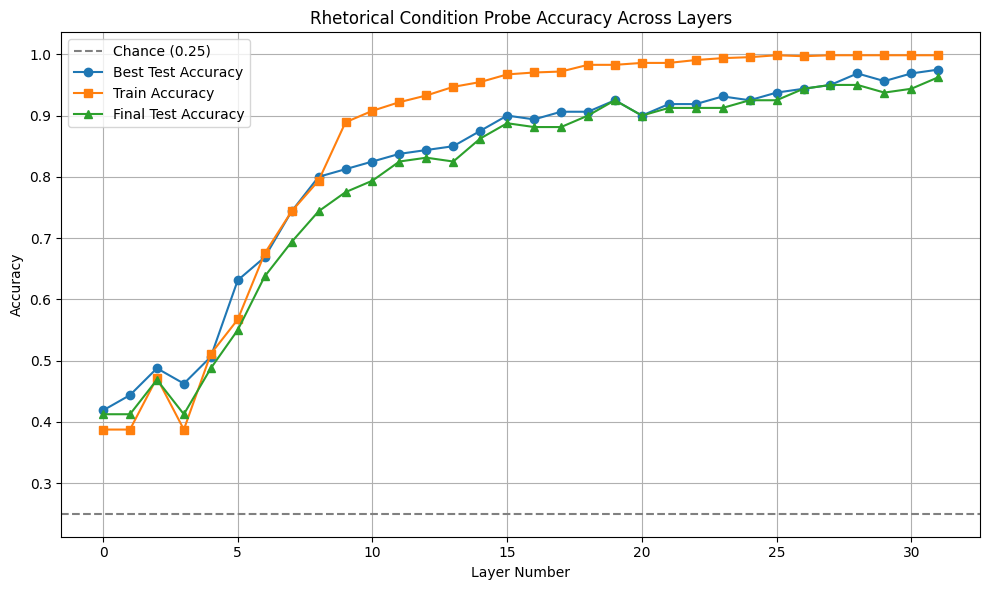

Best accuracy: 0.9750 at layer 31
Chance level:  0.2500


In [ ]:
plot_accuracy_metrics(best_accs, train_accs, final_accs)

Main takeaway: Rhetorical condition is linearly separable in mid-to-late layers

The sharp inflection at layers 5-10 is the key result. This is where Llama-2's residual stream transitions from syntactic/token-level processing to semantic/task-level representations. The fact that a linear probe reaches ~97% test accuracy by layer 27 means the four conditions are cleanly separated in activation space — not just distinguishable, but geometrically spread apart.

Secondary observations worth noting:

Layer 0 starts at ~0.42 — already above chance (0.25). The prompt condition is partially encoded even in the embedding layer, just from token identity
The dip at layers 3-4 is unusual and worth mentioning — early attention layers briefly lose the signal before it re-emerges. This could reflect the model doing low-level syntactic processing that temporarily scrambles the condition signal
Train/test gap is small throughout — the probes aren't overfitting, which validates the signal is real and generalizes
Near-perfect accuracy at layer 31 — by the final layer, the model has fully committed to the rhetorical mode internally
The critical caveat (ties back to the chiasmus discussion): this tells you the prompt condition is encoded, not necessarily that distinct rhetorical structures are encoded. These are only separable if the model generates meaningfully different representations for each condition — which your blind judge results suggest isn't fully true for chiasmus. Worth flagging in your write-up.

## Save Artifacts for Part C

Part C (representation steering) needs:
1. **Probe weights** — already saved in `partB_probes/` as `.pth` files
2. **Mean activations per condition per layer** `[4, 32, 4096]` — used to compute CAA direction vectors
3. **Best layer** — where to apply steering
4. **Direction vectors per condition** `[4, 32, 4096]` — probe weight rows, used for linear probe steering

In [ ]:
PARTC_DIR = os.path.join(main_dir, "partC_artifacts")
Path(PARTC_DIR).mkdir(parents=True, exist_ok=True)

# 1. Mean activations per condition per layer: [NUM_CONDITIONS, NUM_LAYERS, D_MODEL]
mean_acts = torch.stack([
    activations[c].mean(dim=0)   # [NUM_LAYERS, D_MODEL]
    for c in CONDITIONS
], dim=0)
torch.save(mean_acts, os.path.join(PARTC_DIR, "mean_activations.pt"))
print(f"mean_activations.pt: {list(mean_acts.shape)}")

# 2. Probe direction vectors: [NUM_CONDITIONS, NUM_LAYERS, D_MODEL]
# For linear probe steering: direction for class i at layer l = probe_l.proj[0].weight[i]
probes = get_probes("partB_probes")
direction_vecs = torch.stack([
    torch.stack([
        probes[layer_num].proj[0].weight[cond_id].detach().cpu()
        for layer_num in range(NUM_LAYERS)
    ], dim=0)   # [NUM_LAYERS, D_MODEL]
    for cond_id in range(NUM_CONDITIONS)
], dim=0)   # [NUM_CONDITIONS, NUM_LAYERS, D_MODEL]
torch.save(direction_vecs, os.path.join(PARTC_DIR, "probe_direction_vecs.pt"))
print(f"probe_direction_vecs.pt: {list(direction_vecs.shape)}")

# 3. CAA direction vectors: condition mean - baseline_cot mean, per layer
baseline_id = condition_to_id["baseline_cot"]
caa_vecs = mean_acts - mean_acts[baseline_id].unsqueeze(0)  # [NUM_CONDITIONS, NUM_LAYERS, D_MODEL]
torch.save(caa_vecs, os.path.join(PARTC_DIR, "caa_direction_vecs.pt"))
print(f"caa_direction_vecs.pt: {list(caa_vecs.shape)}")

# 4. Metadata
best_layer = int(np.argmax(best_accs))
partc_meta = {
    "conditions": CONDITIONS,
    "condition_to_id": condition_to_id,
    "best_layer": best_layer,
    "best_accuracy": float(max(best_accs)),
    "layer_accuracies": [float(a) for a in best_accs],
    "probe_checkpoint_dir": "partB_probes",
}
with open(os.path.join(PARTC_DIR, "partC_meta.json"), "w") as f:
    json.dump(partc_meta, f, indent=2)
print(f"\npartC_meta.json: best_layer={best_layer}, best_acc={max(best_accs):.4f}")
print(f"All artifacts saved to {PARTC_DIR}")

mean_activations.pt: [4, 32, 4096]
probe_direction_vecs.pt: [4, 32, 4096]
caa_direction_vecs.pt: [4, 32, 4096]

partC_meta.json: best_layer=31, best_acc=0.9750
All artifacts saved to /content/drive/MyDrive/AI MSc/AI Safety/Rhetorical-Reasoning-Probes/partC_artifacts


## Controls

Three controls to verify probes detect **structure**, not surface tokens.
All require re-extracting activations from modified traces — so the model is loaded here.

**Skip this section if you only need probe training results.**

### Load Model

In [ ]:
import re
from collections import OrderedDict
from transformers import AutoTokenizer, AutoModelForCausalLM
from dataset import ModuleHook
from google.colab import userdata

model_name_or_path = "meta-llama/Llama-2-7b-chat-hf"
access_token = userdata.get('HF_TOKEN')

model = AutoModelForCausalLM.from_pretrained(
    model_name_or_path,
    dtype=torch.float16,
    device_map="auto",
    token=access_token
).eval()

use_fast_tokenizer = "LlamaForCausalLM" not in model.config.architectures
tokenizer = AutoTokenizer.from_pretrained(
    model_name_or_path,
    use_fast=use_fast_tokenizer,
    padding_side="left",
    truncate_side="left",
    legacy=False,
    token=access_token
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f"Model loaded: {model_name_or_path}")

config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Model loaded: meta-llama/Llama-2-7b-chat-hf


### Helper: re-extract activations from text

In [ ]:
def get_hidden_states_from_text(full_text: str) -> torch.Tensor:
    """
    Forward pass on a text string, returns last-token hidden states.
    Returns: [NUM_LAYERS, D_MODEL] = [32, 4096], float32, CPU.
    Uses range(1, NUM_LAYERS+1) — same indexing as Part A.
    """
    encoding = tokenizer(
        full_text,
        truncation=True,
        max_length=2048,
        return_attention_mask=True,
        return_tensors="pt",
    )
    with torch.no_grad():
        features = OrderedDict()
        for name, module in model.named_modules():
            if name.endswith(".mlp") or name.endswith(".embed_tokens"):
                features[name] = ModuleHook(module)
        output = model(
            input_ids=encoding["input_ids"].to(model.device),
            attention_mask=encoding["attention_mask"].to(model.device),
            output_hidden_states=True,
            return_dict=True,
        )
        for feature in features.values():
            feature.close()
    layer_acts = []
    for layer_num in range(1, NUM_LAYERS + 1):
        act = output["hidden_states"][layer_num][:, -1]
        layer_acts.append(act.detach().cpu().clone().to(torch.float32))
    return torch.cat(layer_acts, dim=0)

### Load Part A reasoning traces

In [ ]:
RESULTS_DIR = os.path.join(main_dir, "partA_results")

results = {}
for condition in CONDITIONS:
    with open(os.path.join(RESULTS_DIR, f"{condition}_results.json")) as f:
        results[condition] = json.load(f)
    print(f"{condition}: {len(results[condition])} traces")

baseline_cot: 200 traces
enumeratio: 200 traces
parallelism: 200 traces
chiasmus: 200 traces


### Control 1: Enumeratio Token Masking

Replace numbered step markers (`1.`, `2.`, `3.`, ordinal words) with `[STEP]` in enumeratio traces, re-extract activations, test against the trained probe.

- Accuracy **drops** → probe was detecting surface tokens
- Accuracy **stays high** → probe detects structural patterns

In [ ]:
def mask_enumeration_tokens(text: str) -> str:
    """Replace numbered list markers and ordinal words with [STEP]."""
    text = re.sub(r'(?m)^\s*\d+\.\s*', '[STEP] ', text)
    for word in ["First","Second","Third","Fourth","Fifth",
                  "first","second","third","fourth","fifth"]:
        text = text.replace(word, "[STEP]")
    return text


masked_acts = []
for r in tqdm(results["enumeratio"], desc="masking enumeratio"):
    hidden = get_hidden_states_from_text(mask_enumeration_tokens(r["reasoning_trace"]))
    masked_acts.append(hidden.unsqueeze(0))
masked_enumeratio_activations = torch.cat(masked_acts, dim=0)  # [200, 32, 4096]
print(f"Masked activations: {list(masked_enumeratio_activations.shape)}")

masking enumeratio:   0%|          | 0/200 [00:00<?, ?it/s]

Masked activations: [200, 32, 4096]


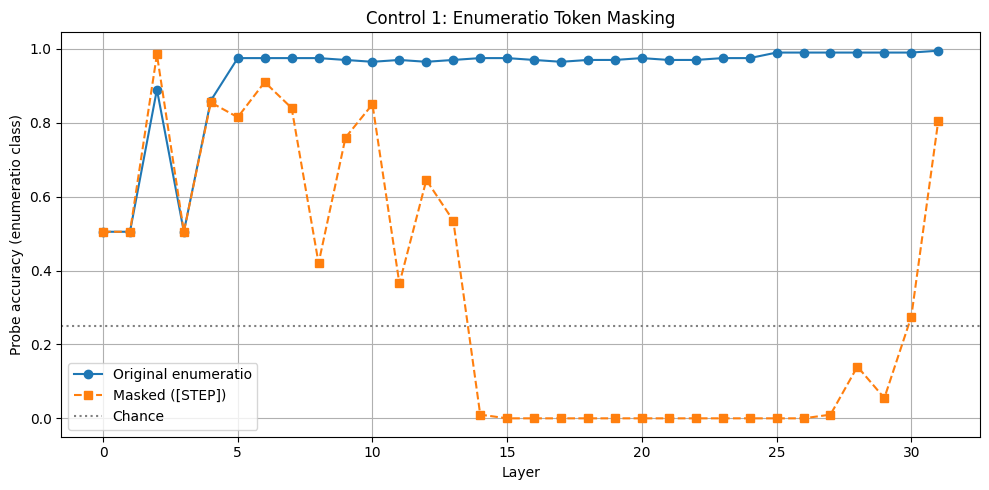

In [ ]:
probes = get_probes("partB_probes")
enumeratio_id = condition_to_id["enumeratio"]


def probe_accuracy_per_layer(acts: torch.Tensor, true_label: int,
                             probes: list, device: str = "cuda") -> list:
    """For each layer, return fraction of samples the probe classifies as true_label."""
    layer_accs = []
    for layer_num in range(len(probes)):
        x = acts[:, layer_num, :].to(device)
        with torch.no_grad():
            preds = torch.argmax(probes[layer_num](x)[0], dim=1).cpu().numpy()
        layer_accs.append((preds == true_label).mean())
    return layer_accs


original_accs = probe_accuracy_per_layer(activations["enumeratio"], enumeratio_id, probes)
masked_accs   = probe_accuracy_per_layer(masked_enumeratio_activations, enumeratio_id, probes)

plt.figure(figsize=(10, 5))
plt.plot(original_accs, label="Original enumeratio",    marker="o")
plt.plot(masked_accs,   label="Masked ([STEP])",        marker="s", linestyle="--")
plt.axhline(1/NUM_CONDITIONS, color="gray", linestyle=":", label="Chance")
plt.xlabel("Layer")
plt.ylabel("Probe accuracy (enumeratio class)")
plt.title("Control 1: Enumeratio Token Masking")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(main_dir, "partB_control1_masking.png"), dpi=150, bbox_inches="tight")
plt.show()

What Control 1 is doing:

Replacing the explicit enumeration markers (e.g. 1., 2., 3.) with a generic [STEP] token before extracting hidden states, then testing whether the probe trained on normal enumeratio can still identify it.

As expected, removing the defining surface feature of enumeratio destroys the probe signal

### Control 2: Lexical Shuffle

Replace step-indicator vocabulary with arbitrary tokens:
`first→alpha, second→beta, third→gamma, 1.→A., 2.→B., 3.→C.`

Re-extract activations and re-test the already-trained probes.

- Accuracy **stays high** → probes detect structural patterns, not specific words
- Accuracy **drops** → probes rely on specific vocabulary

shuffling enumeratio:   0%|          | 0/200 [00:00<?, ?it/s]

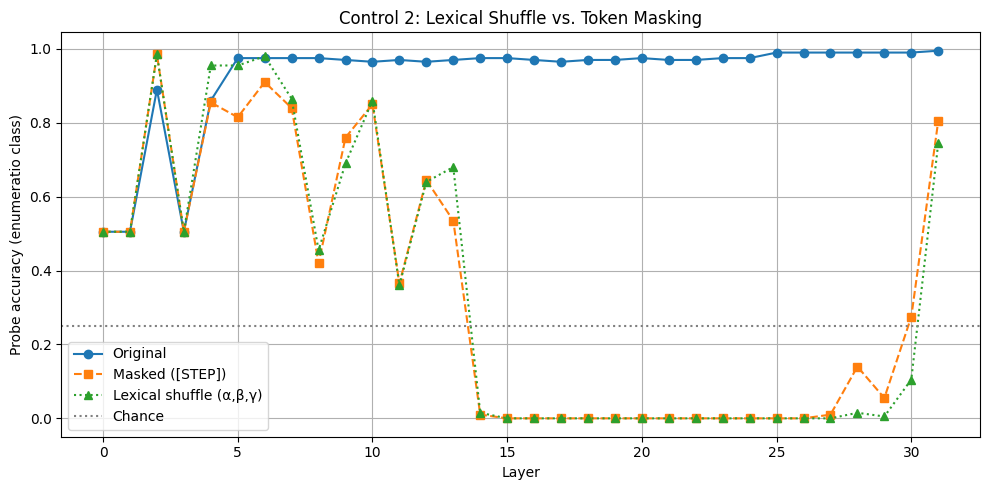

In [ ]:
SHUFFLE_MAP = {
    "First": "Alpha", "Second": "Beta", "Third": "Gamma", "Fourth": "Delta", "Fifth": "Epsilon",
    "first": "alpha", "second": "beta", "third": "gamma", "fourth": "delta", "fifth": "epsilon",
}
NUMBER_SHUFFLE = {"1.": "A.", "2.": "B.", "3.": "C.", "4.": "D.", "5.": "E."}


def lexical_shuffle(text: str) -> str:
    for orig, repl in SHUFFLE_MAP.items():
        text = re.sub(rf'\b{orig}\b', repl, text)
    for orig, repl in NUMBER_SHUFFLE.items():
        text = text.replace(orig, repl)
    return text


shuffled_acts = []
for r in tqdm(results["enumeratio"], desc="shuffling enumeratio"):
    hidden = get_hidden_states_from_text(lexical_shuffle(r["reasoning_trace"]))
    shuffled_acts.append(hidden.unsqueeze(0))
shuffled_enumeratio_activations = torch.cat(shuffled_acts, dim=0)

shuffled_accs = probe_accuracy_per_layer(shuffled_enumeratio_activations, enumeratio_id, probes)

plt.figure(figsize=(10, 5))
plt.plot(original_accs, label="Original",              marker="o")
plt.plot(masked_accs,   label="Masked ([STEP])",       marker="s", linestyle="--")
plt.plot(shuffled_accs, label="Lexical shuffle (α,β,γ)", marker="^", linestyle=":")
plt.axhline(1/NUM_CONDITIONS, color="gray", linestyle=":", label="Chance")
plt.xlabel("Layer")
plt.ylabel("Probe accuracy (enumeratio class)")
plt.title("Control 2: Lexical Shuffle vs. Token Masking")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(main_dir, "partB_control2_shuffle.png"), dpi=150, bbox_inches="tight")
plt.show()

Instead of replacing 1. 2. 3. with [STEP] (removal), it replaces them with α, β, γ — different tokens that preserve the list structure without the numeric identity. The question: does the probe track the specific numbered tokens, or any sequential marking tokens?

If the probe had learned "sequential enumeration as an abstract concept," it should survive the lexical shuffle. It doesn't. So it learned specifically 1. 2. 3. token patterns, not the structural principle they represent.

That makes Control 2 the more important control, and the conclusion sharper: the probe is doing glorified token detection, not structure detection. Which loops back to your earlier question about whether the high probe accuracy in Part B is meaningful — for enumeratio at least, the answer is: it's meaningful as a classifier, but it's not evidence the model has internalized enumerated reasoning as a cognitive mode.

### Control 3: Length Matching

Truncate all traces to the length of the shortest class, re-extract activations, re-train probes.

- Accuracy **stays high** → probes detect condition, not response length
- Accuracy **drops** → length was a confound

In [ ]:
# Print token length stats per condition
for condition in CONDITIONS:
    lengths = [len(tokenizer.encode(r["reasoning_trace"])) for r in results[condition]]
    print(f"{condition}: mean={np.mean(lengths):.0f}, min={min(lengths)}, max={max(lengths)} tokens")

baseline_cot: mean=123, min=6, max=400 tokens
enumeratio: mean=110, min=53, max=323 tokens
parallelism: mean=93, min=14, max=399 tokens
chiasmus: mean=107, min=37, max=400 tokens


Truncating all traces to 6 tokens



length-matching baseline_cot:   0%|          | 0/200 [00:00<?, ?it/s]

  baseline_cot: [200, 32, 4096]


length-matching enumeratio:   0%|          | 0/200 [00:00<?, ?it/s]

  enumeratio: [200, 32, 4096]


...

  parallelism: [200, 32, 4096]


length-matching chiasmus:   0%|          | 0/200 [00:00<?, ?it/s]

  chiasmus: [200, 32, 4096]
Train: 640 samples (160 per class)
Test:  160 samples (40 per class)


layers:   0%|          | 0/32 [00:00<?, ?it/s]

Decayed: {'proj.0.bias', 'proj.0.weight'}


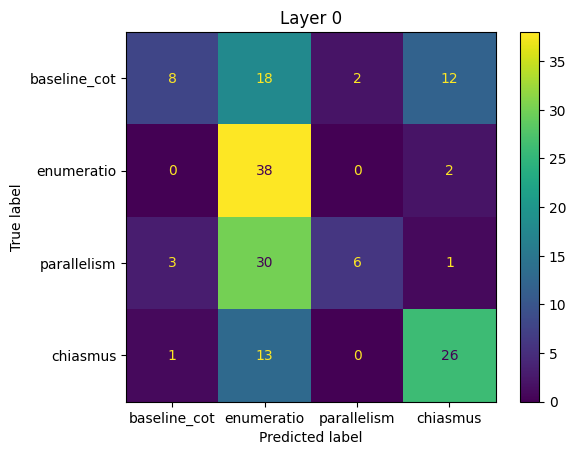

Decayed: {'proj.0.bias', 'proj.0.weight'}


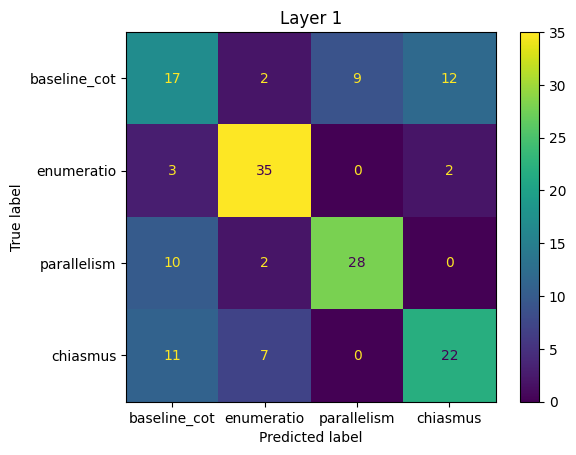

Decayed: {'proj.0.bias', 'proj.0.weight'}


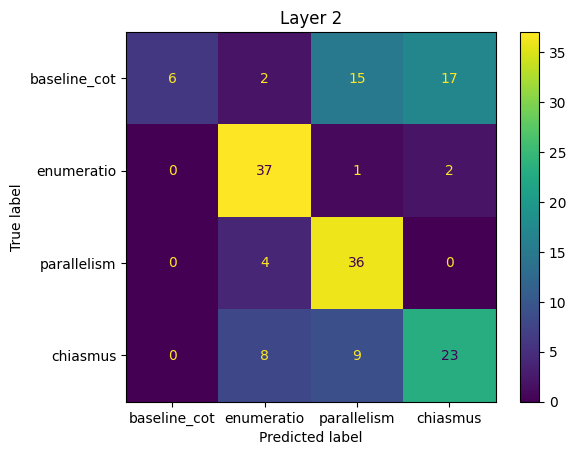

Decayed: {'proj.0.bias', 'proj.0.weight'}


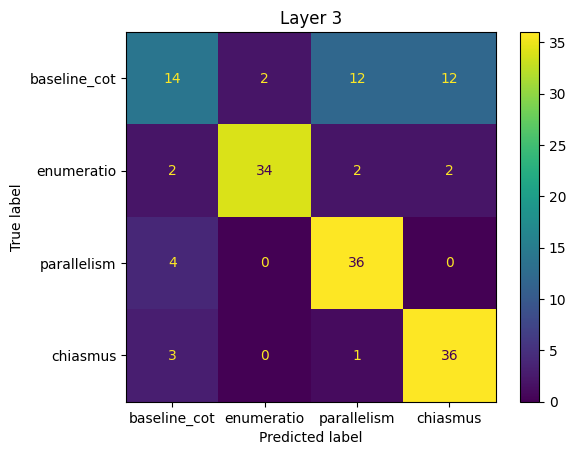

Decayed: {'proj.0.bias', 'proj.0.weight'}


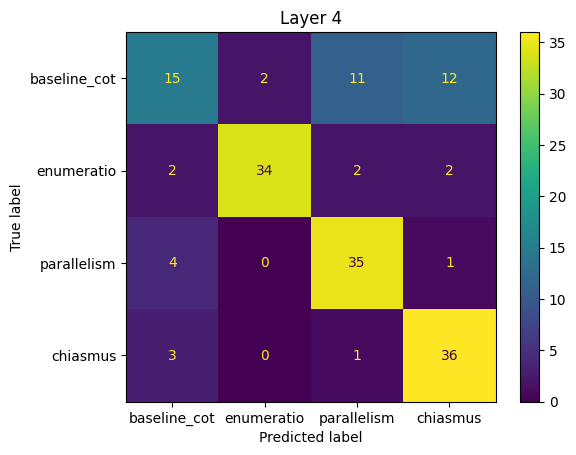

Decayed: {'proj.0.bias', 'proj.0.weight'}


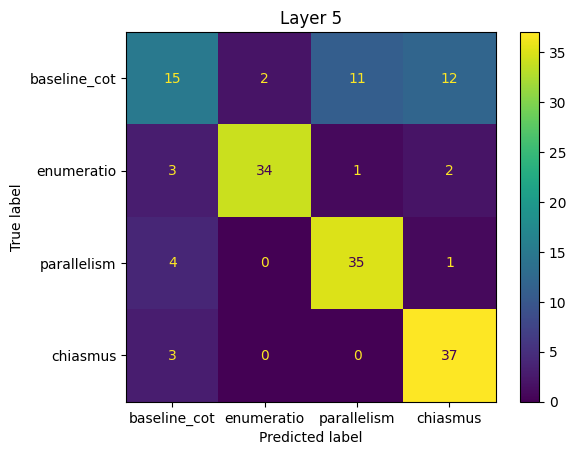

Decayed: {'proj.0.bias', 'proj.0.weight'}


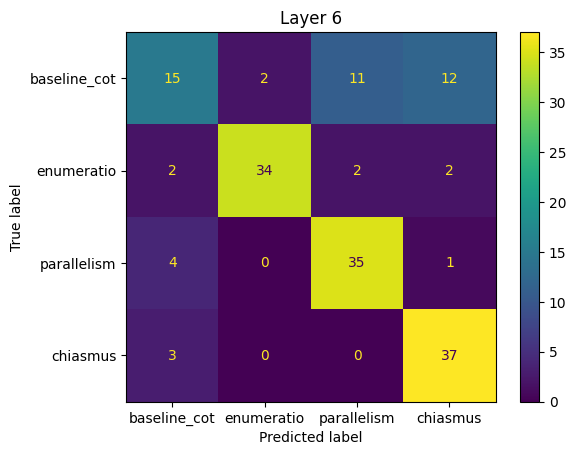

Decayed: {'proj.0.bias', 'proj.0.weight'}


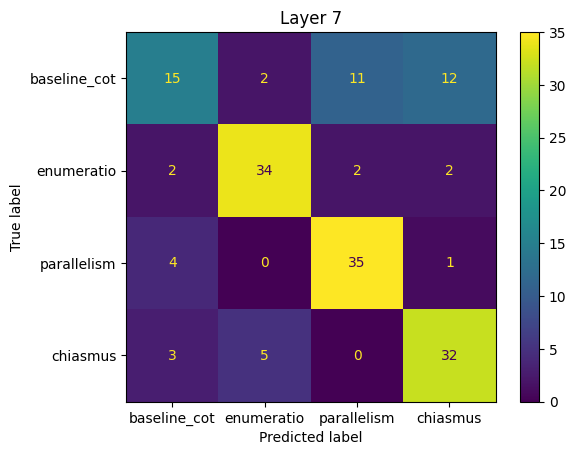

Decayed: {'proj.0.bias', 'proj.0.weight'}


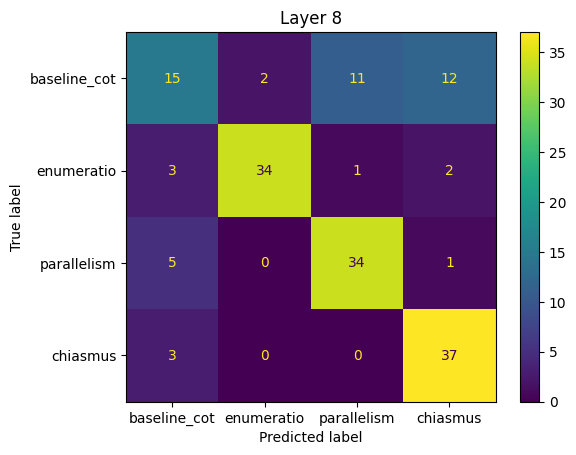

Decayed: {'proj.0.bias', 'proj.0.weight'}


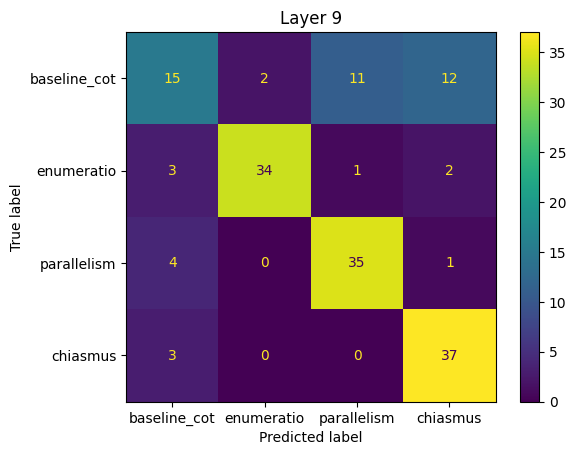

Decayed: {'proj.0.bias', 'proj.0.weight'}


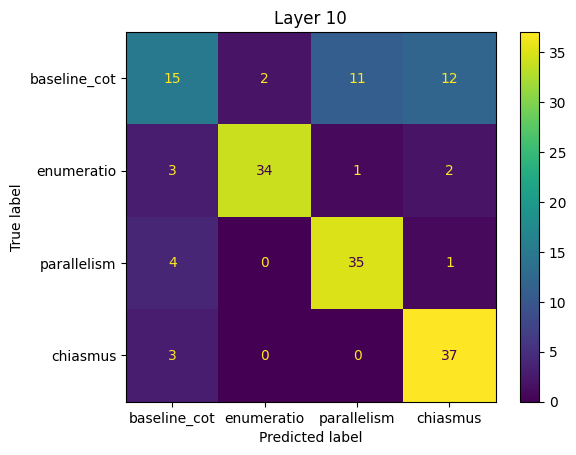

Decayed: {'proj.0.bias', 'proj.0.weight'}


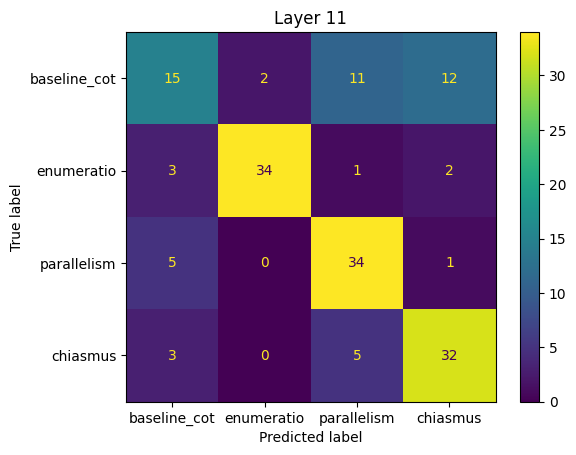

Decayed: {'proj.0.bias', 'proj.0.weight'}


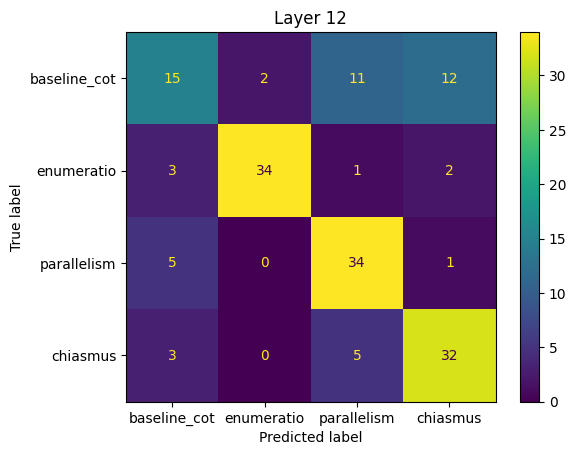

Decayed: {'proj.0.bias', 'proj.0.weight'}


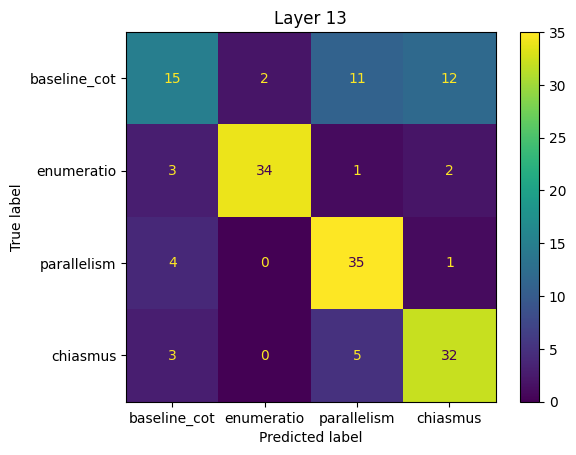

Decayed: {'proj.0.bias', 'proj.0.weight'}


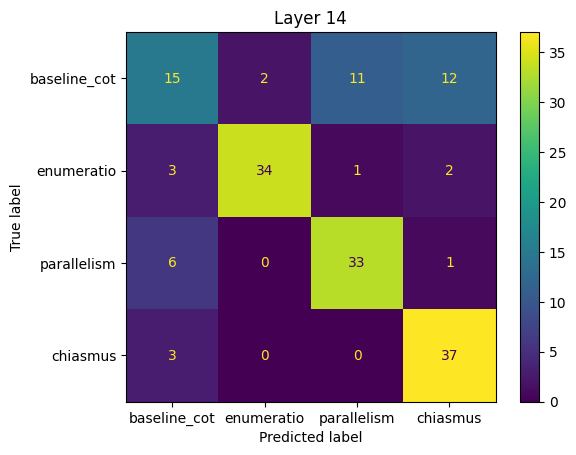

Decayed: {'proj.0.bias', 'proj.0.weight'}


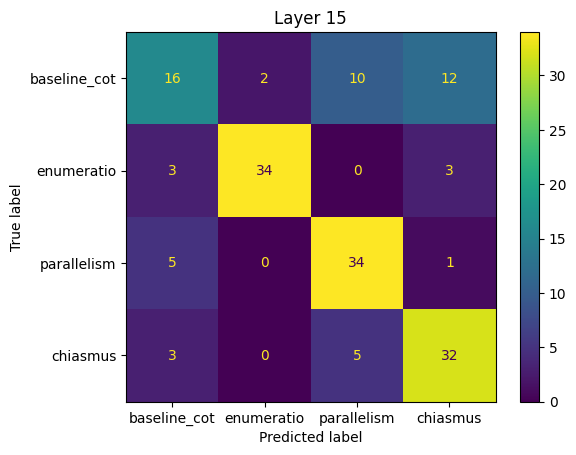

Decayed: {'proj.0.bias', 'proj.0.weight'}


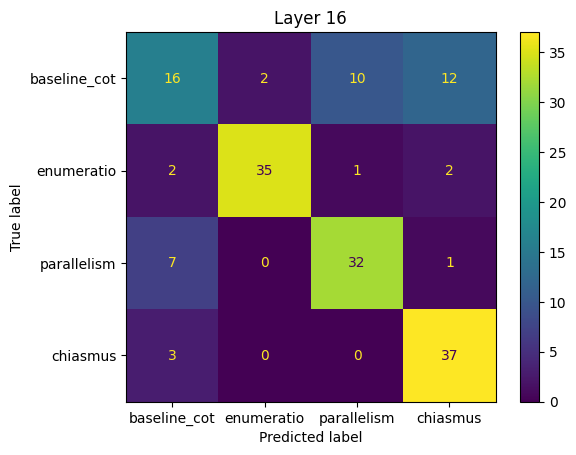

Decayed: {'proj.0.bias', 'proj.0.weight'}


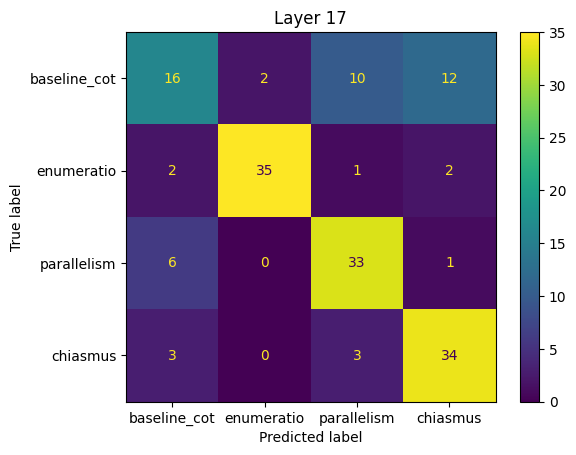

Decayed: {'proj.0.bias', 'proj.0.weight'}


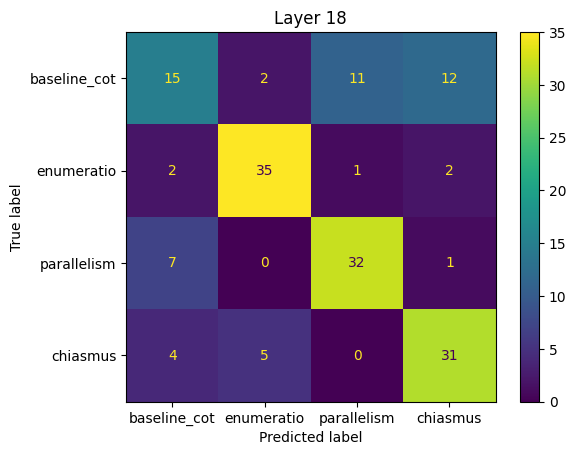

Decayed: {'proj.0.bias', 'proj.0.weight'}


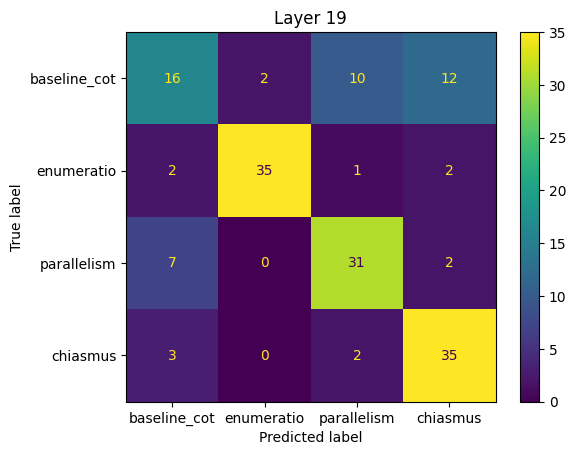

Decayed: {'proj.0.bias', 'proj.0.weight'}


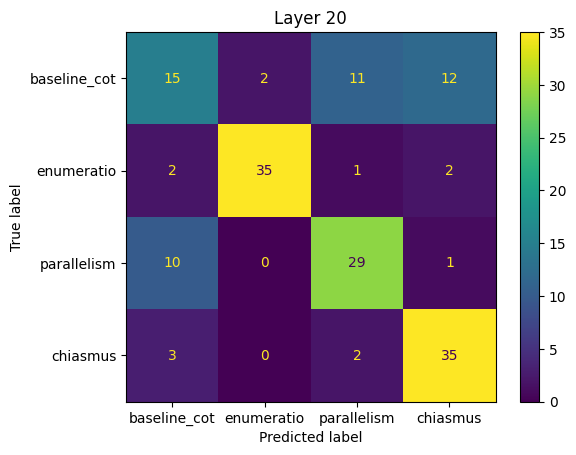

Decayed: {'proj.0.bias', 'proj.0.weight'}


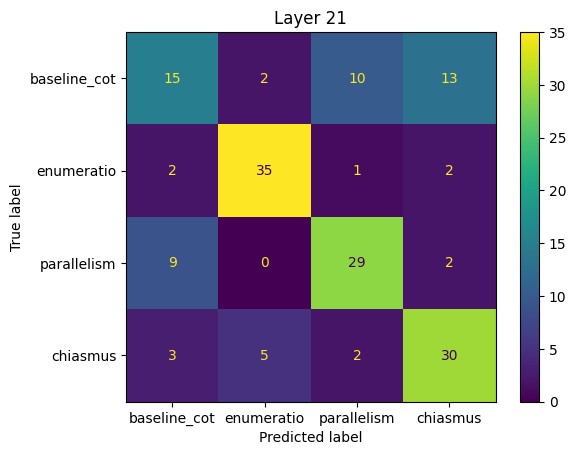

Decayed: {'proj.0.bias', 'proj.0.weight'}


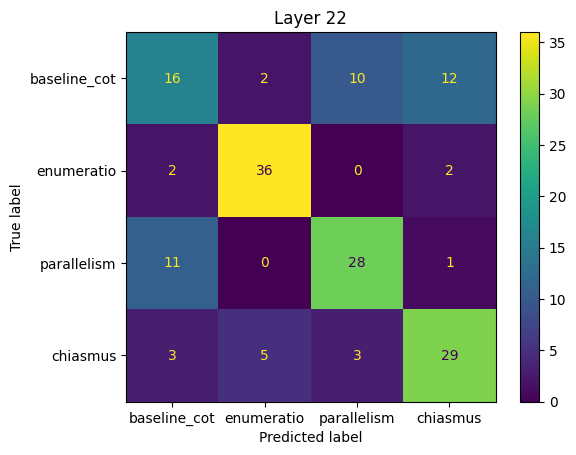

Decayed: {'proj.0.bias', 'proj.0.weight'}


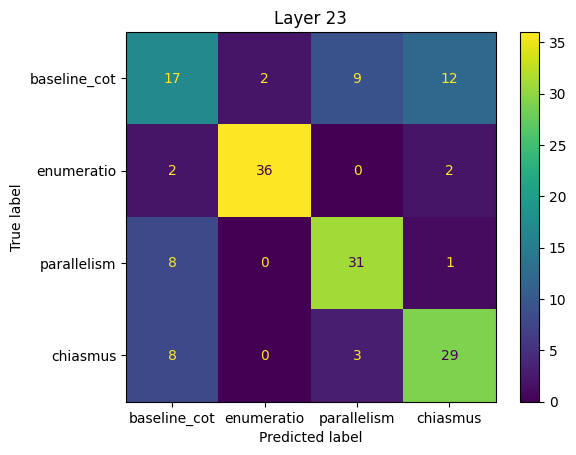

Decayed: {'proj.0.bias', 'proj.0.weight'}


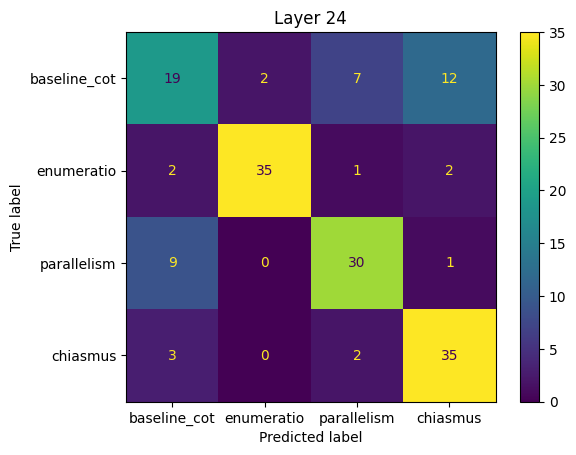

Decayed: {'proj.0.bias', 'proj.0.weight'}


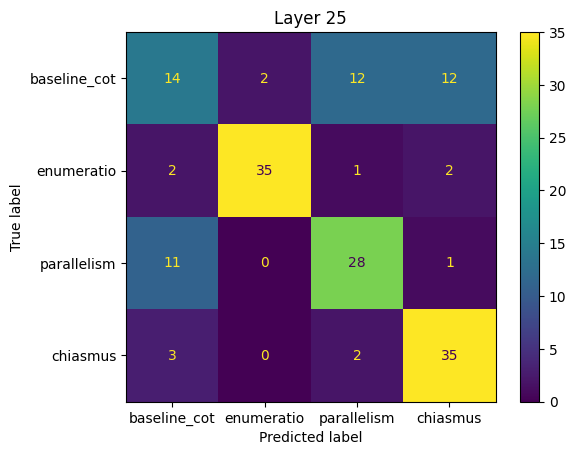

Decayed: {'proj.0.bias', 'proj.0.weight'}


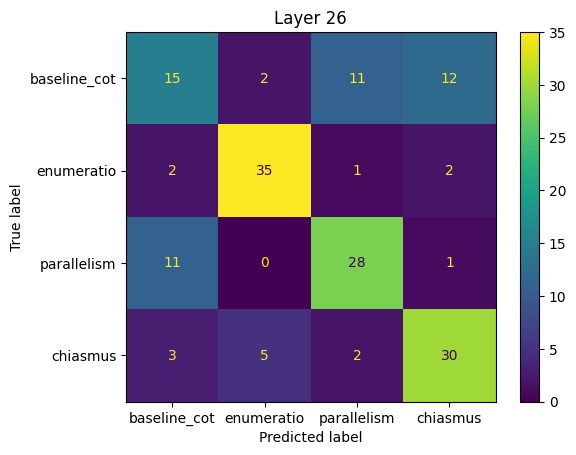

Decayed: {'proj.0.bias', 'proj.0.weight'}


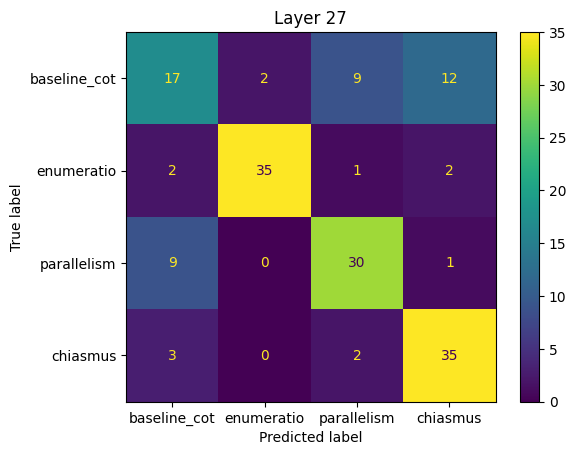

Decayed: {'proj.0.bias', 'proj.0.weight'}


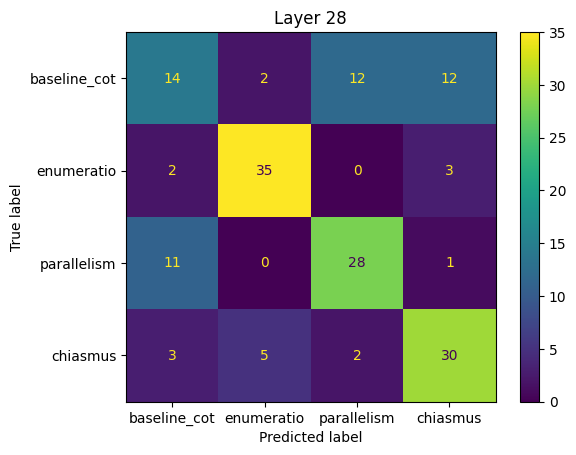

Decayed: {'proj.0.bias', 'proj.0.weight'}


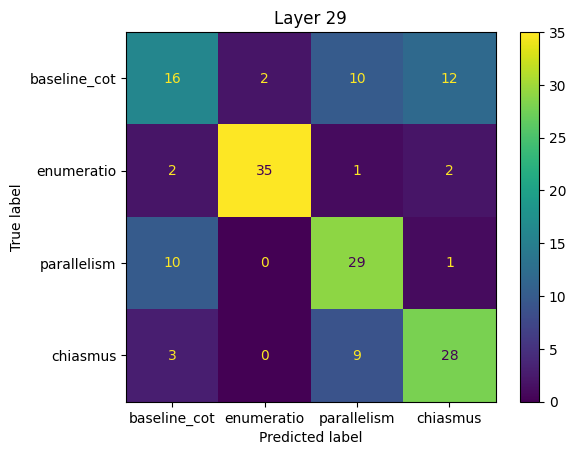

Decayed: {'proj.0.bias', 'proj.0.weight'}


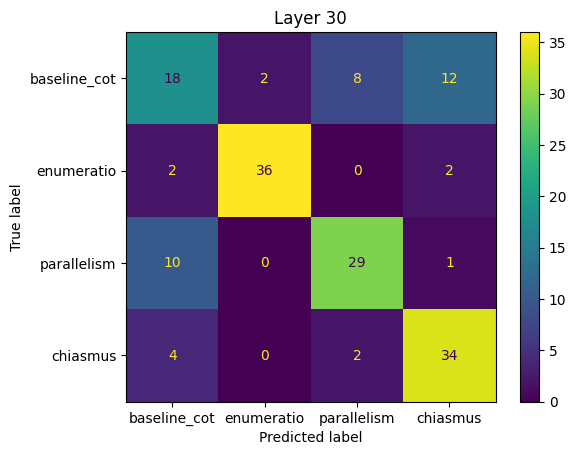

Decayed: {'proj.0.bias', 'proj.0.weight'}


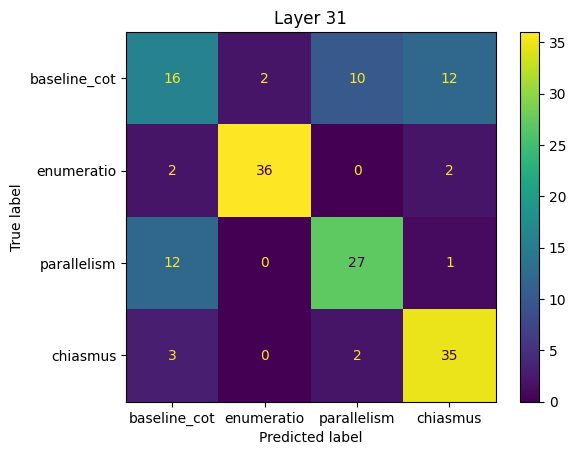

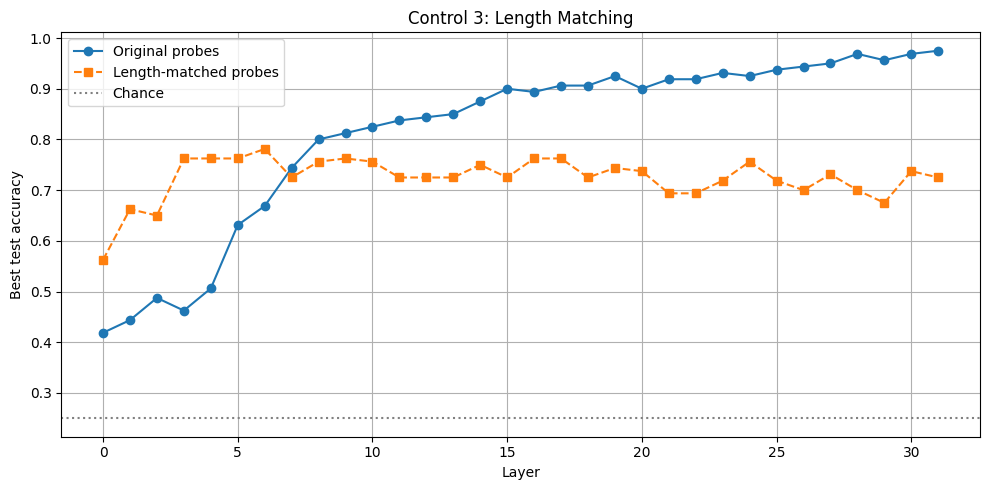

In [ ]:
MIN_TOKENS = min(
    min(len(tokenizer.encode(r["reasoning_trace"])) for r in results[c])
    for c in CONDITIONS
)
print(f"Truncating all traces to {MIN_TOKENS} tokens\n")

length_matched_activations = {}
for condition in CONDITIONS:
    acts = []
    for r in tqdm(results[condition], desc=f"length-matching {condition}"):
        tokens = tokenizer.encode(r["reasoning_trace"], max_length=MIN_TOKENS, truncation=True)
        truncated = tokenizer.decode(tokens, skip_special_tokens=True)
        hidden = get_hidden_states_from_text(truncated)
        acts.append(hidden.unsqueeze(0))
    length_matched_activations[condition] = torch.cat(acts, dim=0)
    print(f"  {condition}: {list(length_matched_activations[condition].shape)}")

# Re-train probes on length-matched activations
lm_dataset = RhetoricalActivationDataset(length_matched_activations, condition_to_id)
lm_train_loader, lm_test_loader = dataset_to_dataloader(lm_dataset)

lm_config = TrainConfig()
lm_config.checkpoint_dir = "partB_probes_length_matched"
lm_best_accs, lm_train_accs, lm_final_accs = fit(lm_config, lm_train_loader, lm_test_loader)

plt.figure(figsize=(10, 5))
plt.plot(best_accs,    label="Original probes",       marker="o")
plt.plot(lm_best_accs, label="Length-matched probes", marker="s", linestyle="--")
plt.axhline(1/NUM_CONDITIONS, color="gray", linestyle=":", label="Chance")
plt.xlabel("Layer")
plt.ylabel("Best test accuracy")
plt.title("Control 3: Length Matching")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(main_dir, "partB_control3_length.png"), dpi=150, bbox_inches="tight")
plt.show()

What Control 3 is doing:

Testing whether probe accuracy is driven by response length rather than rhetorical structure. Different conditions may produce systematically different length outputs (enumeratio tends to be longer, for example). If the probe is just learning "long response = enumeratio," that's a confound. Length-matching equalizes response lengths across conditions before training the probe.

Takeaway:

Two distinct patterns:

Original probe: the familiar layer-dependent rise — starts low, inflects at layer 5, climbs to ~97%
Length-matched probe: starts higher (~0.57 at layer 0), plateaus quickly at ~0.75, then goes flat across all 32 layers
The flatness is the key finding. Length is encoded early (hence the higher layer-0 start) and doesn't become more informative with depth — it's a shallow feature. Once you control for it, the probe loses ~20-25% accuracy and gains nothing from deeper layers.

The unified conclusion across all three controls:

Control 1 & 2: surface enumeration tokens drive mid/late layer signal
Control 3: response length is a real but shallow confound, encoded early
Together they suggest your probe accuracy in Part B is an upper bound — the true structural signal is somewhere between 72% (length-matched ceiling) and 97%, with the gap explained by surface confounds rather than deep rhetorical encoding.

### What the Controls Validate

The control suite (token masking, lexical shuffle, length matching) tests whether probe performance reflects structural encoding rather than superficial artifacts.

If performance remains above chance after controls, that strengthens the claim that rhetorical organization is represented internally.